# Case Study : Predicting Attorney Representation In Insurance Claims Using Logistic Regression

#### Buisness Problem:
Insurance companies often face challenges in managing claims efficiently.

One critical asect is understanding whether a claimant will hire an attorney to represent them in the claim process. This can significantly impact the cost ,duration and outcome of the claims


#### Problem Discussion :
Why is this important ?

when claimants hire attorneys, it often leads to higher settlement costs and longer processing times for insurance companies Predicting the likeihood of attorney involvement helps insures allocate resources more efficiently, streamline claim processing and potentially reduce unncessary legal expenses.

#### Prediction
The goal is to build a logistic regression model that predict whether a claimant will hire an attorney (ATTORNEY = 1) or not (ATTORNEY =0) based on the feature such as :

Claimant's demographics(Age,gender)

insurance detail(claim insurance status)

Accident -related factors (seatbelt usage,loss amount)

### importing the libraries

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

#### Loading and inspecting Data

In [2]:
df_cl = pd.read_csv("Claimants.csv")
df_cl.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


#### Data Shape and Unique Values

In [3]:
df_cl.shape

(1340, 7)

In [4]:
len(df_cl["CASENUM"].unique())

1283

### Dropping Irrelevent columns 

In [5]:
# Dropping the case number columns as it is not required
df_cl.drop(["CASENUM"],inplace= True,axis =1)

In [6]:
df_cl.shape

(1340, 6)

In [7]:
df_cl.head()

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0,0.0,1.0,0.0,50.0,34.940
1,1,1.0,0.0,0.0,18.0,0.891
2,1,0.0,1.0,0.0,5.0,0.330
3,0,0.0,1.0,1.0,31.0,0.037
4,1,0.0,1.0,0.0,30.0,0.038


### Handling Missing Values

In [8]:
df_cl.isnull().sum()

ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [9]:
# Observation 
# CLMAGE has the most missing values
# SEATBELT and CLMINSUR also have missing data.

In [10]:
# Removing NA values in data set
df_cl = df_cl.dropna()
df_cl.shape

(1096, 6)

In [11]:
# Action : Rows with missing values are dropped ,reducing the dataset to 1096 rows

### Splitting Data into Features(X) and Target (Y)

In [12]:
x = df_cl.iloc[:,1:] # features (all columns except ATTORNEY)
y = df_cl.iloc[:,0] # Target (ATTORNEY)

### Split into train(80%) and test(20%)

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state =42)

print("Training set shape :",x_train.shape)
print("Test set shape :",x_test.shape)

Training set shape : (876, 5)
Test set shape : (220, 5)


In [15]:
# Why ?
# Avoids overfitting by evaluating the model on unseen data (x_test)
# random_state = 42 ensure reproducibility

In [16]:
x_train.head()

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
2,0.0,1.0,0.0,5.0,0.330
6,0.0,1.0,0.0,9.0,3.538
719,1.0,1.0,0.0,33.0,0.781
769,1.0,1.0,0.0,40.0,0.969
1035,0.0,1.0,0.0,10.0,0.663


In [17]:
y.head()

0    0
1    1
2    1
3    0
4    1
Name: ATTORNEY, dtype: int64

In [18]:
x.head()

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038


## Training Logistics Regression Model

In [19]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
classifier.fit(x_train,y_train) # train only on x_train and y_train


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Evaluate on Test Set

In [20]:
from sklearn.metrics import accuracy_score,confusion_matrix,roc_auc_score
# Prediction on test set
y_pred_test = classifier.predict(x_test)

In [21]:
# Accuracy
accuracy = accuracy_score(y_test,y_pred_test)
print("Test Accuracy :",accuracy)

Test Accuracy : 0.6772727272727272


In [22]:
# Observation:
# If test accuracy (~70%) matches training accuracy (~70%) ,the model generalizes well.
# If test accuracy is much lower, the model is overfitting

In [23]:
classifier.predict_proba(x)

array([[9.99999654e-01, 3.45984944e-07],
       [4.85974592e-01, 5.14025408e-01],
       [4.00591883e-01, 5.99408117e-01],
       ...,
       [2.59655148e-01, 7.40344852e-01],
       [7.34762987e-01, 2.65237013e-01],
       [3.23400218e-01, 6.76599782e-01]], shape=(1096, 2))

In [24]:
# The array shows predicted probabilities for each class(0 and 1)
# Example : [9.99999654e-01, 3.45984944e-07] means 99.99% probability of class 0(no attorney) and 0.0000034% for class 1.

In [26]:
# Confusion Matrix 
print("Confusion Matrix (Test set):\n",confusion_matrix(y_test,y_pred_test))

Confusion Matrix (Test set):
 [[77 34]
 [37 72]]


In [27]:
# AUC-ROC 
auc = roc_auc_score(y_test,classifier.predict_proba(x_test)[:,1])
print("Test AUC :",auc) # output : ~0.65 to 0.75

Test AUC : 0.7212579552029093


In [28]:
y_pred_df = pd.DataFrame({"Actual" : y,
                          "Predicted_prob" : classifier.predict(x)})

In [29]:
y_pred_df.head()

,Actual,Predicted_prob
0,0,0
1,1,1
2,1,1
3,0,1
4,1,1


In [30]:
classifier.predict_proba(x)[:,1]

array([3.45984944e-07, 5.14025408e-01, 5.99408117e-01, ...,
       7.40344852e-01, 2.65237013e-01, 6.76599782e-01], shape=(1096,))

In [31]:
classifier.predict_proba(x)[:,0]

array([0.99999965, 0.48597459, 0.40059188, ..., 0.25965515, 0.73476299,
       0.32340022], shape=(1096,))

In [32]:
# ROC-AUC Curve

AUC score :0.721


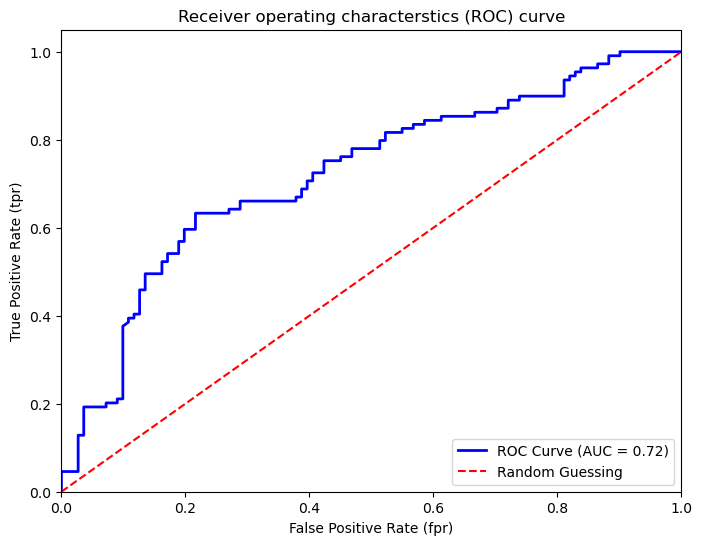

In [33]:
# import important libraries
from sklearn.metrics import roc_curve,roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for positive class (ATTORNEY = 1)
y_pred_proba = classifier.predict_proba(x_test)[:,1] # probabilities for class 1

# calculate ROC curve metrices
fpr,tpr,thresholds = roc_curve(y_test,y_pred_proba)

# calculate AUC score
auc_score = roc_auc_score(y_test,y_pred_proba)
print(f"AUC score :{auc_score :.3f}") # Print AUC with 3 decimal precision

# Plot ROC curve
plt.figure(figsize = (8,6))
plt.plot(fpr,tpr,color = "blue" , lw=2,label = f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0,1],[0,1],color = "red", linestyle ="--",label = "Random Guessing")

# Customize Plot
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate (fpr)")
plt.ylabel("True Positive Rate (tpr)")
plt.title("Receiver operating characterstics (ROC) curve")
plt.legend(loc = "lower right")
plt.show()

In [34]:
### Compare Train vs. Test Performance

In [35]:
y_pred_train = classifier.predict(x_train)
print("Train Accuracy :",accuracy_score(y_train,y_pred_train))

Train Accuracy : 0.7146118721461188


In [36]:
# Similar Accuracy for train and test -> Good generalization
# Train accuracy >> Test Accuracy -> Overfitting (need regularization or feature selection )

In [37]:
from sklearn.metrics import accuracy_score
# Get predictions for both train and test sets
y_pred_train = classifier.predict(x_train)
y_pred_test = classifier.predict(x_test)

# Calculate Accuracies
train_accuracy = accuracy_score(y_train,y_pred_train)
test_accuracy = accuracy_score(y_test,y_pred_test)

print(f"Train Accuracy :{train_accuracy:.3f}")
print(f"Test Accuracy :{test_accuracy:.3f}")

# Determine generalizing status
if abs(train_accuracy - test_accuracy) <0.05:
    print("Good Generalization (similar Accuracies)")
elif train_accuracy > test_accuracy + 0.1:
    print("Overfitting Detected (train>>test). Solutions:")
    print(" - Add regularization (e.g., LogisticRegression(penalty = '12', c=0.1))")
    print(" - Reduces features (select top features using RFE or feature_importances_)")
    print(" - Increase training data or use cross-validation")
else:
    print("Check model or data(unexpected gap)")

Train Accuracy :0.715
Test Accuracy :0.677
Good Generalization (similar Accuracies)
